In [3]:
import sudoku_solver as ss
import sudoku_archive as sa
import sudoku_visualization as sv

import matplotlib.pyplot as plt

## 6. Esempi guidati

### 6.1 Un puzzle facile

Un classico puzzle "easy": ci si aspetta che basti la famiglia degli
inserimenti diretti (Naked/Hidden Single).

In [2]:
easy_puzzle = (
    "530070000"
    "600195000"
    "098000060"
    "800060003"
    "400803001"
    "700020006"
    "060000280"
    "000419005"
    "000080079"
)

easy_result = ss.analyse_puzzle(easy_puzzle, name='easy')
print("Stato:", easy_result['status'])
print("Valutazione difficoltà:", easy_result['grading'])

Stato: solved
Valutazione difficoltà: {'label': 'Fondamentale', 'max_difficulty': 1, 'score': 1.0, 'histogram': {1: 51, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0}, 'status': 'solved', 'n_steps': 51}


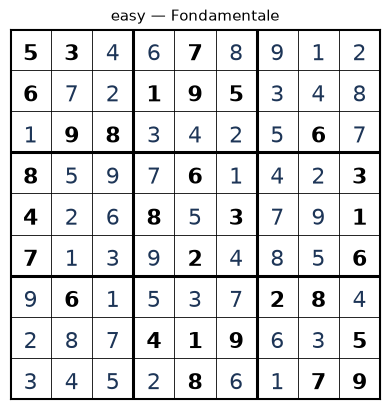

In [4]:
sv.draw_grid(easy_result['solved_grid'], given_mask=(easy_result['original'] != 0),
           title=f"{easy_result['name']} — {easy_result['grading']['label']}")
plt.show()

### 6.2 Un puzzle che richiede tecniche intermedie/avanzate

Generiamo un puzzle con soluzione unica e clue count medio-basso, per avere
buone probabilità che servano tecniche oltre i semplici single. Se il primo
tentativo risulta comunque troppo facile (può succedere, dipende dalla
griglia casuale), si può rieseguire la cella con un altro seed.

In [ ]:
rng = random.Random(12)
gen_puzzle, gen_full_solution = generate_unique_puzzle(target_clues=28, rng=rng)

hard_result = analyse_puzzle(gen_puzzle, name='generato')
print("Stato:", hard_result['status'])
print("Valutazione difficoltà:", hard_result['grading'])

tecniche_usate = {}
for m in hard_result['chain']:
    tecniche_usate[m['technique']] = tecniche_usate.get(m['technique'], 0) + 1
print("Tecniche usate nella catena:", tecniche_usate)

Vista d'insieme della catena logica: difficoltà per step, colorata per famiglia di tecnica, più istogramma dei livelli.

In [ ]:
plot_difficulty_chain(hard_result)

Ispezione di un singolo passaggio: si può cambiare `step_index` per
scorrere la catena e vedere esattamente dove la tecnica è stata applicata
sulla griglia (celle gialle = pattern che definisce la mossa, celle rosa =
celle modificate).

In [ ]:
# indice dello step più difficile della catena, tanto per mostrarne uno interessante
if hard_result['chain']:
    hardest_idx = max(range(len(hard_result['chain'])),
                       key=lambda i: hard_result['chain'][i]['difficulty'])
    draw_step(hard_result, hardest_idx)

Tabella completa della catena, come DataFrame pandas.

In [ ]:
summary_dataframe(hard_result)

## 7. Galleria finale

Analizziamo e salviamo un piccolo insieme di puzzle (alcuni fissi, alcuni
generati) e li visualizziamo tutti insieme, ciascuno con la propria
etichetta di difficoltà. `saved_analyses` è la lista che raccoglie ogni
puzzle analizzato in questa sessione: si può continuare ad aggiungerne altri
richiamando `analyse_puzzle` e facendo `saved_analyses.append(...)` in
qualunque punto del notebook, poi rilanciare le celle di questa sezione per
aggiornare galleria e riepilogo.

In [ ]:
saved_analyses = []

# un paio di puzzle fissi, per avere sempre un riferimento noto
saved_analyses.append(easy_result)

medium_puzzle = (
    "020840009"
    "090000060"
    "600000002"
    "003401800"
    "000000000"
    "004503200"
    "500000004"
    "030000070"
    "800097040"
)
saved_analyses.append(analyse_puzzle(medium_puzzle, name='medium'))

# alcuni puzzle generati con target di indizi diversi -> difficoltà attesa crescente
for target in [34, 30, 27]:
    rng_i = random.Random(target)
    p, _ = generate_unique_puzzle(target_clues=target, rng=rng_i)
    saved_analyses.append(analyse_puzzle(p, name=f'generato_{target}clue'))

saved_analyses.append(hard_result)

In [ ]:
report_rows = []
for res in saved_analyses:
    g = res['grading']
    report_rows.append({
        'nome': res['name'],
        'stato': res['status'],
        'etichetta_difficolta': g['label'],
        'livello_max': g['max_difficulty'],
        'punteggio': g['score'],
        'n_step': g.get('n_steps', 0),
    })
import pandas as pd
pd.DataFrame(report_rows)

Galleria visiva di tutti i puzzle salvati finora.

In [ ]:
gallery(saved_analyses, ncols=3)

### Confronto delle catene

Un'unica figura con la catena di difficoltà di ogni puzzle salvato,
per confrontare a colpo d'occhio quanto e quando ciascuno richiede
tecniche più avanzate.

In [ ]:
for res in saved_analyses:
    if res['chain']:
        plot_difficulty_chain(res, figsize=(10, 3))
    else:
        print(f"{res['name']}: nessuno step registrato (già risolto o bloccato subito).")

## Note finali

- La classificazione di difficoltà riflette **esattamente** la definizione
  pratica del documento fornito: quanto è difficile individuare a mano il
  pattern, non la complessità della dimostrazione logica.
- Un puzzle che il motore segna come "stuck" non è necessariamente
  irrisolvibile: significa che servirebbe una tecnica di livello 6 non
  implementata qui (catene forzanti, AIC generali, ALS). Il flag
  `backtracking_verified_solvable` conferma comunque se una soluzione
  esiste.
- Per estendere la copertura (es. Simple Colouring, X-Chain, W-Wing,
  Unique Rectangle Type 2–5, BUG+1) basta aggiungere una nuova funzione con
  la stessa firma `(state) -> list[move]` in `sudoku_techniques.py` e
  registrarla in `TECHNIQUE_FUNCS` con la sua difficoltà minima: il motore
  la userà automaticamente senza altre modifiche.